In [423]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sorted_portfolios import get_sorted_index, get_sorted_portfolio
from utils import *
from signals import *
from visualization import plot_group_cum, plot_solo_cum

plt.style.use("default")
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# CRSP data
crsp = pd.read_csv("csrp_msf.csv", index_col=0)
# Construct dfs
dfs = {}
dfs['prc'] = np.abs(date_cusip_pivot(crsp, 'prc_adj'))
dfs['ret'] = get_simple_ret(dfs['prc'])
dfs['idx_vol_threshold'] = get_volume_threshold(date_cusip_pivot(crsp, "vol"))

In [37]:
# Price momentum
dfs['mom_prc'] = get_momentum(dfs['ret'], 12, 1)

/Users/pengchengzhou/anaconda3/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


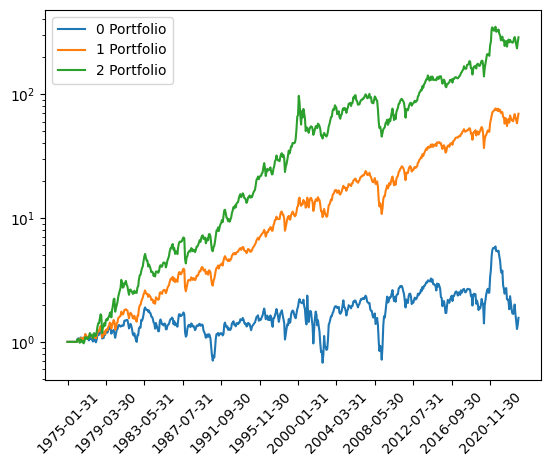

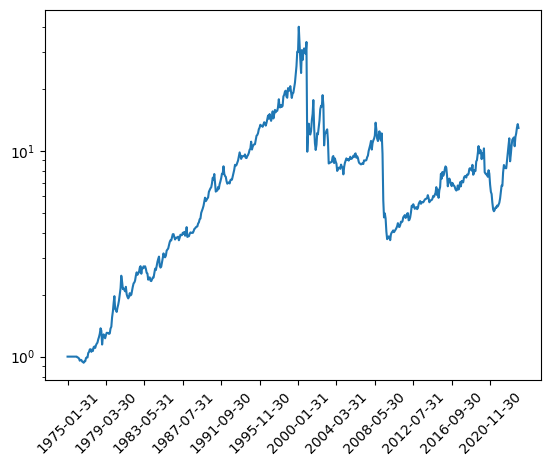

In [125]:
# Portfolio
mom_portfolio = get_sorted_portfolio(
    dfs['ret'], get_sorted_index
    (dfs['mom_prc'] * dfs['idx_vol_threshold'],
     quantiles=np.array([0.3, 0.7])
     ),
    
)

## Comp Funda

In [3]:
comp_funda_og = pd.read_csv("comp_funda.csv", index_col=0).rename(columns={"datadate": "date"})
comp_funda_og['cusip'] = comp_funda_og['cusip'].apply(lambda x: str(x)[:8])
comp_funda_og = comp_funda_og[comp_funda_og.datafmt == 'STD']
comp_funda_og = comp_funda_og[~(comp_funda_og.cusip == "nan")].reset_index(drop=True)
comp_funda_og['date'] = pd.to_datetime(comp_funda_og.date)

/var/folders/ts/rncgzs1x0z9fwh0s8vnmhs2h0000gn/T/ipykernel_99362/2148792859.py:1: DtypeWarning: Columns (9,11,12,13,17,18,23,27,31,34,35,36,921,947,948) have mixed types. Specify dtype option on import or set low_memory=False.
  comp_funda_og = pd.read_csv("comp_funda.csv", index_col=0).rename(columns={"datadate": "date"})


/Users/pengchengzhou/anaconda3/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


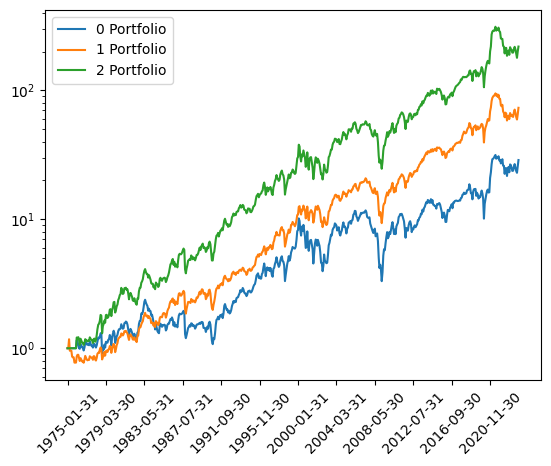

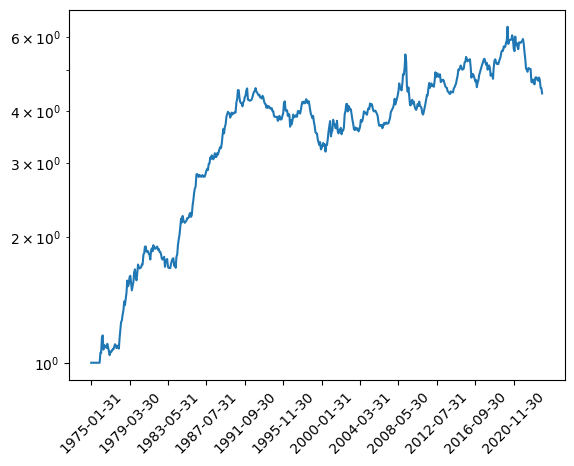

In [41]:
# Portfolio
dfs['pm_pct'] = get_pm_pct_df(comp_funda_og, dfs['ret'])
feature = 'pm_pct'
pm_portfolio = get_sorted_portfolio(
    dfs['ret'], get_sorted_index(
        dfs[feature] * dfs['idx_vol_threshold'], 
        quantiles=np.array([0.3, 0.7])
        )
)

/Users/pengchengzhou/anaconda3/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


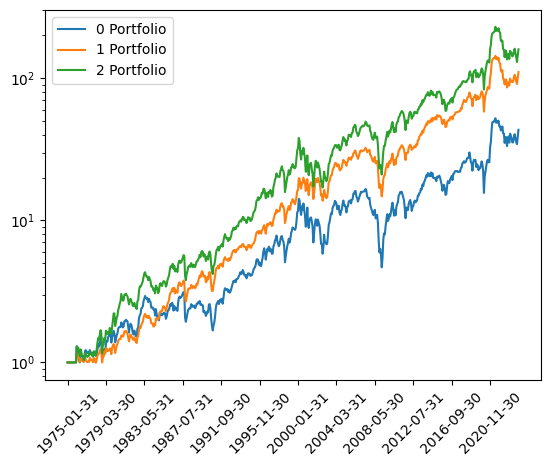

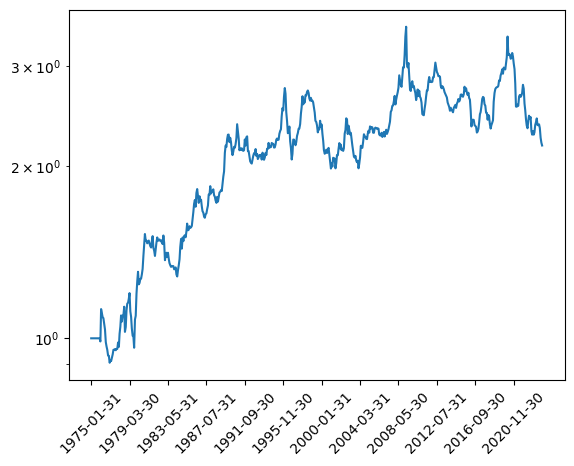

In [42]:
# Portfolio
dfs['eps_pct'] = get_eps_pct_df(comp_funda_og, dfs['ret'], )
feature = 'eps_pct'
pm_portfolio = get_sorted_portfolio(
    dfs['ret'], get_sorted_index(
        dfs[feature] * dfs['idx_vol_threshold'], 
        quantiles=np.array([0.3, 0.7])
        )
)

In [43]:
crsp['me'] = crsp.eval("prc * shrout")

In [44]:
dfs['size'] = date_cusip_pivot(crsp, "me")

In [454]:
df_size = get_size_df(crsp)
#df_size = get_size_df_comp(comp_funda_og, dfs['ret'])
selected_idx = get_certain_month_idx(df_size, month=6)
df_size[~selected_idx] = np.nan

/Users/pengchengzhou/anaconda3/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


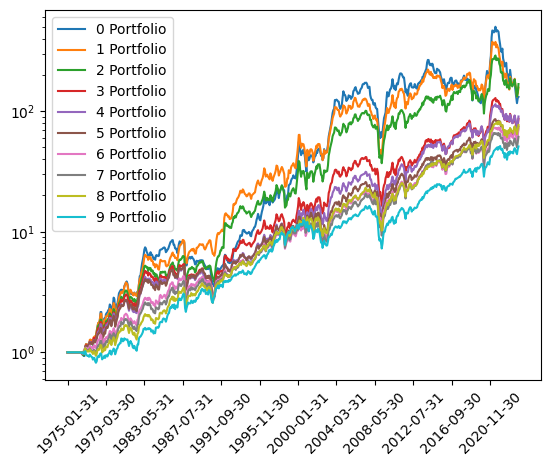

In [690]:

size_portfolio = get_sorted_portfolio(
    dfs['ret'], get_sorted_index(
        df_size * get_volume_threshold(date_cusip_pivot(crsp, "vol"), 0.20),
        #quantiles=np.array([0.2, 0.4, 0.6, 0.8])
        )
)
temp = size_portfolio[
    (size_portfolio.index >= datetime(1999, 7, 1)) & (size_portfolio.index <= datetime(2020, 12, 31))
]

In [707]:
def process_ff(df, s=197501, e=202012):
    df = df / 100
    df = df[(df.index >= s) & (df.index <= e)]
    df.index = df.index.astype(str)
    return df

def ls(df, l, s):
    return df.iloc[:, l] - df.iloc[:, s]

In [692]:
ff_size = process_ff(pd.read_csv('Portfolios_Formed_on_ME.CSV', index_col=0))
#ff_size = ff_size.iloc[:, 4:9]
ff_size = ff_size.iloc[:, 9:]

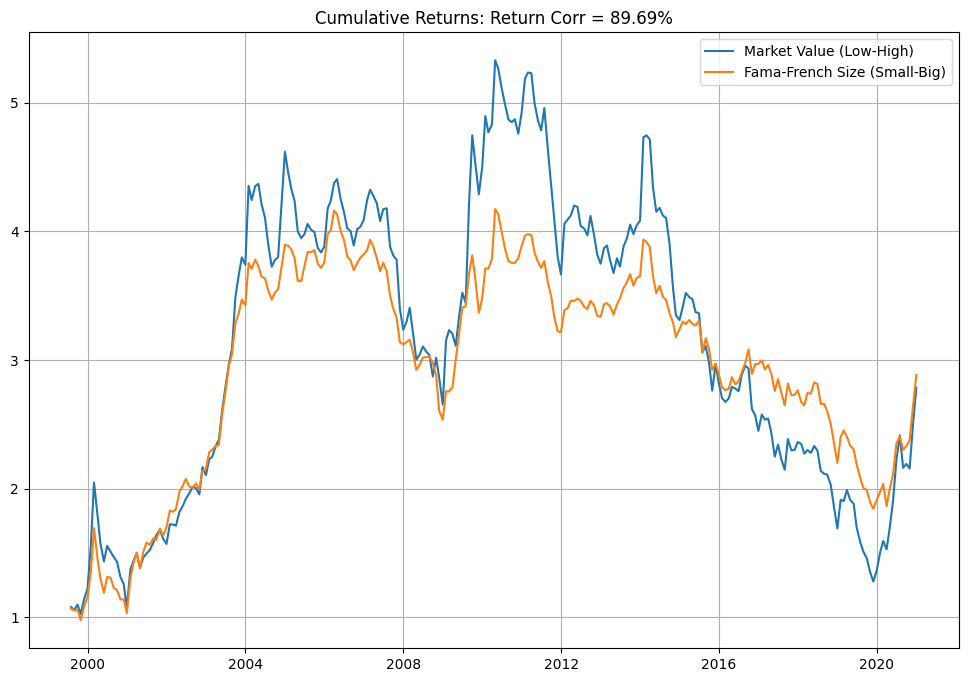

In [693]:
plt.figure(figsize=(12, 8))
plt.plot(temp.index, (1+ls(temp, 0, -1)).to_numpy().cumprod(), label='Market Value (Low-High)')
plt.plot(temp.index, (1+ls(ff_size, 0, -1)).to_numpy().cumprod(), label='Fama-French Size (Small-Big)')
# plt.plot(temp.index, (1+temp.iloc[:, 0]).to_numpy().cumprod(), label='Small')
# plt.plot(temp.index, (1+ff_size.iloc[:, 0]).to_numpy().cumprod(), label='FF Small')
# plt.plot(temp.index, (1+temp.iloc[:, -1]).to_numpy().cumprod(), '--', label='Big')
# plt.plot(temp.index, (1+ff_size.iloc[:,-1]).to_numpy().cumprod(), '--', label='FF Big')
corr = np.corrcoef([ls(temp, 0, -1), ls(ff_size, 0, -1)])[0, 1]
plt.legend(loc='upper right')
plt.title(f"Cumulative Returns: Return Corr = {corr:.2%}")
plt.grid()
plt.show()

In [708]:
ff_mom = pd.read_excel("french_mom_ew.xlsx", index_col=0) / 100

In [709]:
ff_mom = process_ff(ff_mom)

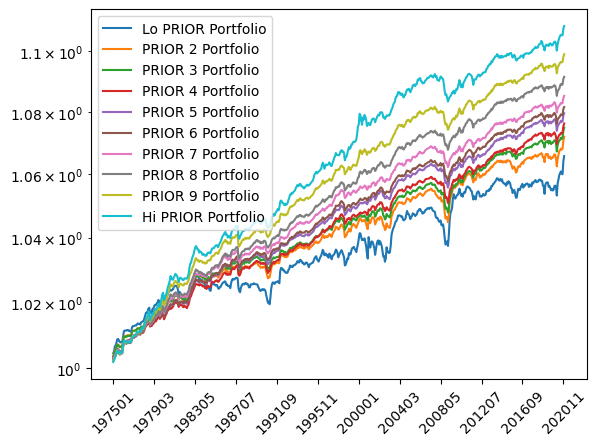

In [710]:
plot_group_cum(ff_mom)

In [697]:
df_mom = get_momentum(dfs['ret'])

/Users/pengchengzhou/anaconda3/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


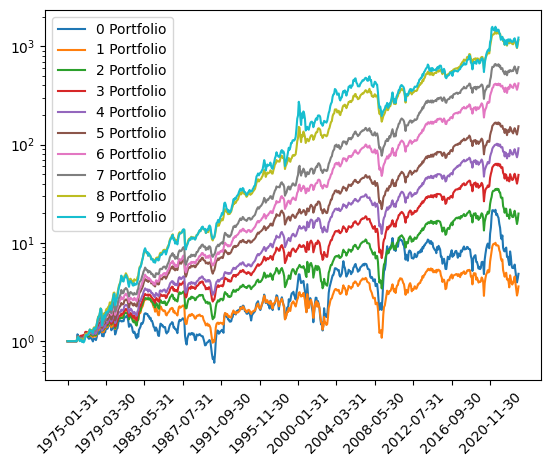

In [717]:
# selected_idx = get_certain_month_idx(df_mom, month=6)
# df_mom[~selected_idx] = np.nan
mom_portfolio = get_sorted_portfolio(
    dfs['ret'], get_sorted_index(
        df_mom * get_volume_threshold(date_cusip_pivot(crsp, "vol"), 0.20),
        holding_period=1
        #quantiles=np.array([0.2, 0.4, 0.6, 0.8])
        )
)
temp_mom = mom_portfolio[
    (mom_portfolio.index >= datetime(1975, 1, 1)) & (mom_portfolio.index <= datetime(2020, 12, 31))
]

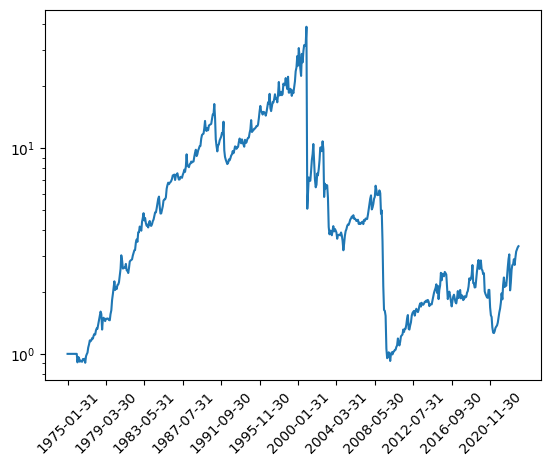

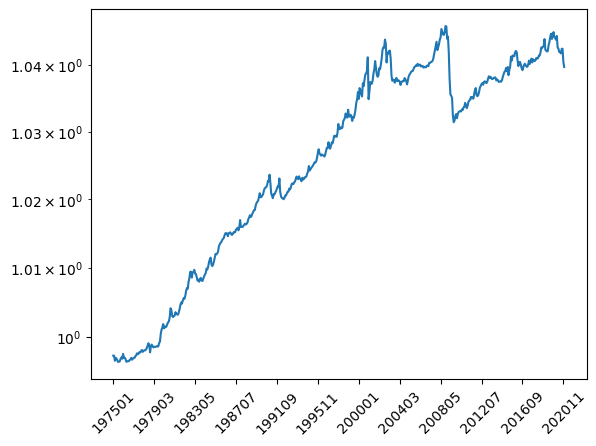

In [715]:
plot_solo_cum(ls(mom_portfolio, -1, 0))
plot_solo_cum(ls(ff_mom, -1, 0))

In [720]:
tst = 1+ls(ff_mom, -1, 0)

In [723]:
tst.cumprod()

197501    0.997299
197502    0.997293
197503    0.996561
197504    0.996984
197505    0.996875
            ...   
202008    1.041702
202009    1.042388
202010    1.042407
202011    1.040439
202012    1.039664
Length: 552, dtype: float64

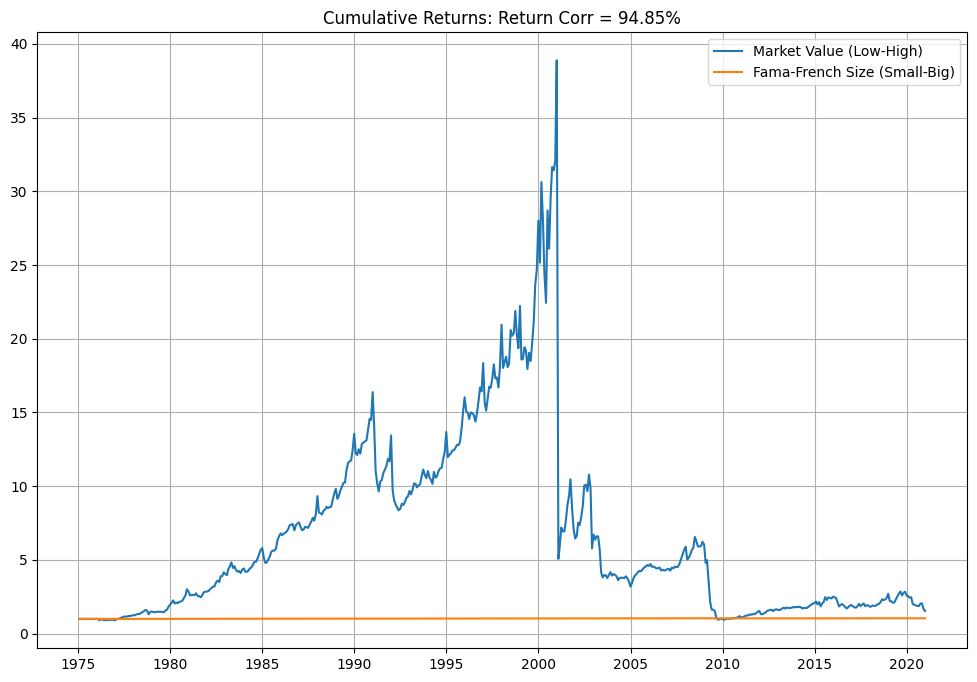

In [718]:
plt.figure(figsize=(12, 8))
plt.plot(temp_mom.index, (1+ls(temp_mom, -1, 0)).to_numpy().cumprod(), label='Market Value (Low-High)')
plt.plot(temp_mom.index, (1+ls(ff_mom, -1, 0)).to_numpy().cumprod(), label='Fama-French Size (Small-Big)')
# plt.plot(temp_mom.index, (1+temp_mom.iloc[:, 0]).to_numpy().cumprod(), label='Small')
# plt.plot(temp_mom.index, (1+ff_mom.iloc[:, 0]).to_numpy().cumprod(), label='FF Small')
# plt.plot(temp_mom.index, (1+temp_mom.iloc[:, -1]).to_numpy().cumprod(), '--', label='Big')
# plt.plot(temp_mom.index, (1+ff_mom.iloc[:,-1]).to_numpy().cumprod(), '--', label='FF Big')
corr = np.corrcoef([ls(temp_mom, -1, 0), ls(ff_mom, -1, 0)])[0, 1]
plt.legend(loc='upper right')
plt.title(f"Cumulative Returns: Return Corr = {corr:.2%}")
plt.grid()
plt.show()